<a href="https://colab.research.google.com/github/mutallimovaydin/Diabetes_130-US_Hospitals_for_Years_1999-2008/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LassoCV
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor

In [2]:
!unzip diabetes+130-us+hospitals+for+years+1999-2008.zip

Archive:  diabetes+130-us+hospitals+for+years+1999-2008.zip
  inflating: diabetic_data.csv       
  inflating: IDS_mapping.csv         


In [3]:
df = pd.read_csv("/content/diabetic_data.csv")

In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# Hedef sutunumuz 'readmitted'dir, '<30' gun = 1 (risklidir), digerleri ('>30' ve ya 'NO') = 0
if 'readmitted' in df.columns:
    df['target'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
    df = df.drop('readmitted', axis=1)

**Data Cleaning**

In [6]:
df = df.replace('?', np.nan)
if 'patient_nbr' in df.columns and 'encounter_id' in df.columns:
    df = df.sort_values('encounter_id').drop_duplicates(subset=['patient_nbr'], keep='first')

In [7]:
columns_to_drop = ['encounter_id', 'patient_nbr']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1)

In [8]:
missing_threshold = 0.5
df = df.dropna(thresh=int((1 - missing_threshold) * len(df)), axis=1)

In [9]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
# One-Hot Encoding edirik
df_encoded = pd.get_dummies(df, drop_first=True)

In [11]:
# X (Xususiyyetler) ve y (Hedef) olaraq ayiririq
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
# İndi ise yalniz Train datasi uzerinde sinif balansini temin edirik
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [14]:
print("Orijinal train setindeki siniflerin paylanmasi:\n", y_train.value_counts(), "\n")
print("SMOTE tetbiqinden sonra train setindeki siniflerin paylanmasi:\n", y_train_resampled.value_counts())

Orijinal train setindeki siniflerin paylanmasi:
 target
0    52180
1     5034
Name: count, dtype: int64 

SMOTE tetbiqinden sonra train setindeki siniflerin paylanmasi:
 target
0    52180
1    52180
Name: count, dtype: int64


In [15]:
import xgboost as xgb
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

print("--- Baza (Baseline) Model Neticeleri ---")
print(f"Accuracy: {accuracy_score(y_test, baseline_preds):.4f}\n")

# Clean column names for XGBoost compatibility
X_train.columns = X_train.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)
X_test.columns = X_test.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

--- Baza (Baseline) Model Neticeleri ---
Accuracy: 0.9120



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("--- XGBoost Model Neticeleri ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

--- XGBoost Model Neticeleri ---
Accuracy: 0.9121
ROC-AUC: 0.6678

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95     13045
           1       0.60      0.00      0.00      1259

    accuracy                           0.91     14304
   macro avg       0.76      0.50      0.48     14304
weighted avg       0.88      0.91      0.87     14304



In [17]:
import shap

shap.initjs()
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

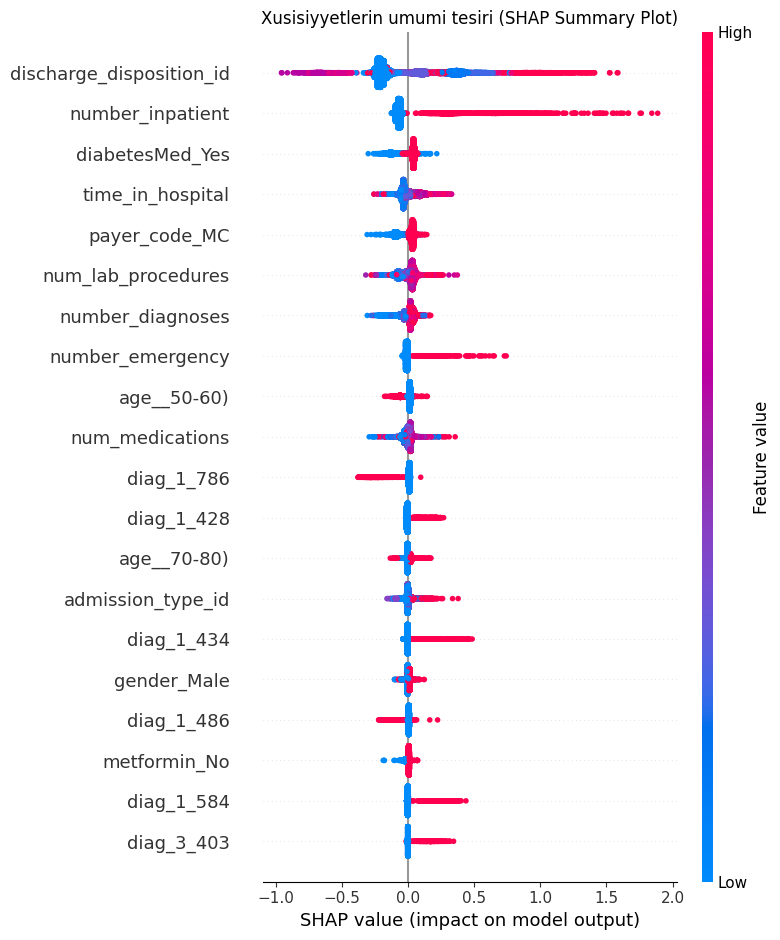

In [18]:
plt.figure(figsize=(10, 6))
plt.title("Xusisiyyetlerin umumi tesiri (SHAP Summary Plot)")
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

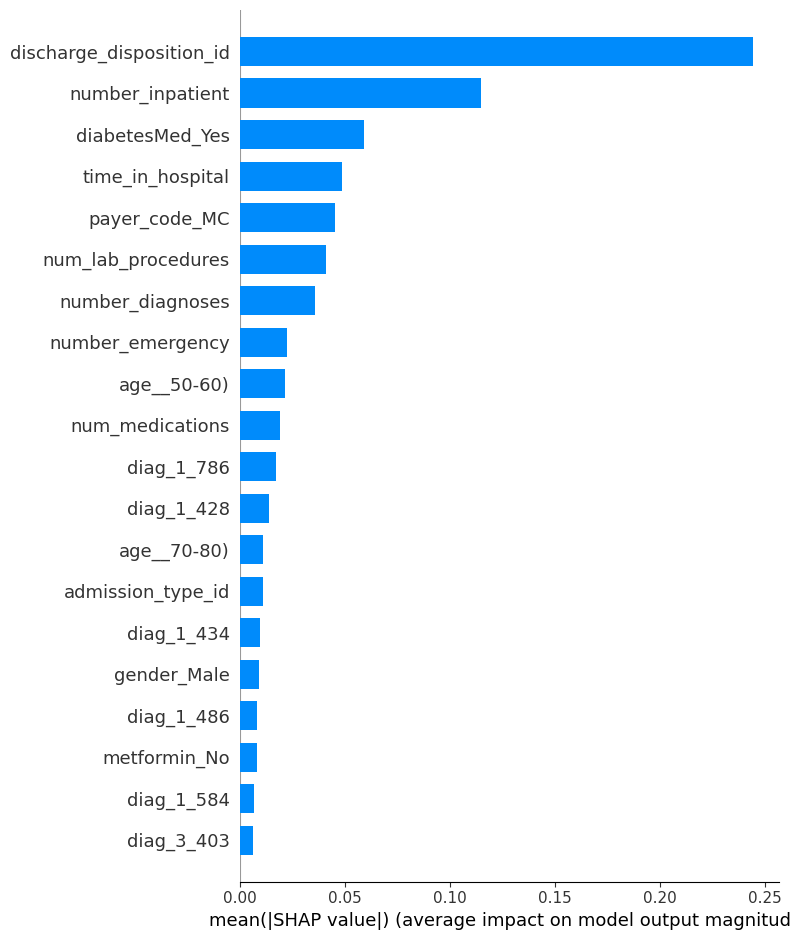

In [19]:
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X_test.columns)

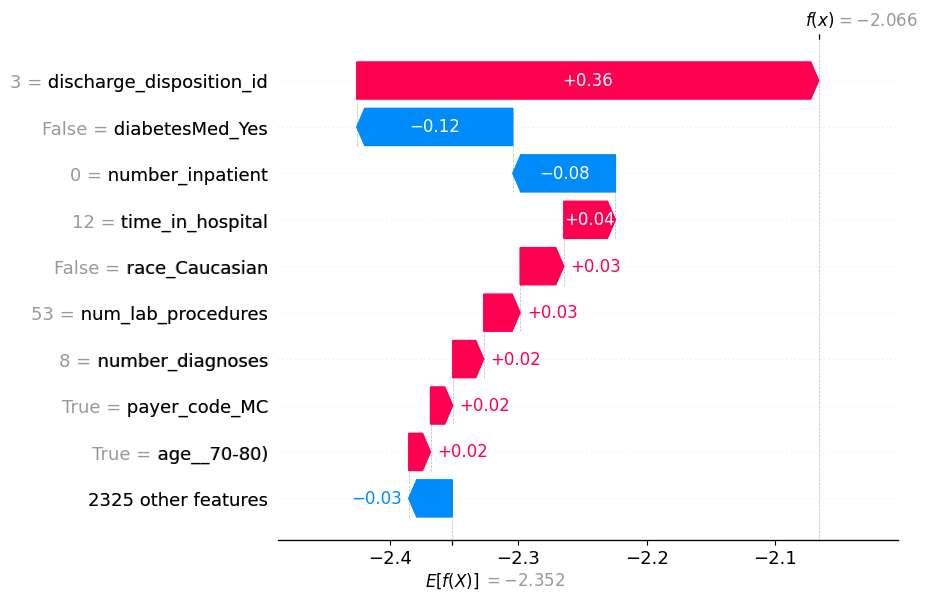

In [20]:
explainer_waterfall = shap.Explainer(xgb_model)
shap_values_waterfall = explainer_waterfall(X_test)
plt.figure()
shap.plots.waterfall(shap_values_waterfall[0])